# XRD spectra simulation

Author: Boris Slautin

powered by [pymatgen](https://pymatgen.org/)




In [19]:
!pip install pymatgen

In [20]:
import numpy as np
import matplotlib.pyplot as plt

## 1 Phase diagramm

=====================================

###Pb(Zr₁₋ₓTiₓ)O₃ (PZT) PHASE DIAGRAM

=====================================

This module defines the crystallographic phase of PZT as a function
of titanium composition `x` and temperature `T`. It provides an
approximate, continuous model suitable for phase-field simulations,
structure factor generation, or diffraction pattern prediction.

The main function `pzt_phase(x, T)` returns a dictionary describing:

* `phase`: qualitative name of the stable phase (cubic, rhombohedral,
  tetragonal, monoclinic, or mixed R+T)
* `symmetry`: associated space group or point group
* `parameters`: lattice constants {a,b,c,alpha,beta,gamma}, including
  optional phase fractions in the coexistence region

The function internally determines:

1. The Curie temperature `Tc(x)` separating ferroelectric and
   paraelectric regions, estimated by a polynomial fit (`Tc_fit`).
2. The morphotropic phase boundary (MPB) range between 0.45 < x < 0.52,
   which controls the transition between rhombohedral and tetragonal
   symmetries, with a monoclinic bridging phase near x ≈ 0.48.
3. Temperature- and composition-dependent lattice parameters derived
from simplified, physically consistent empirical relations.
Vegard-type linear interpolation with respect to composition is
used in the cubic and tetragonal regions to represent solid-solution
behavior, combined with first-order thermal expansion (~1×10⁻⁵/°C).

Behavior by region:

* T > Tc(x): cubic paraelectric phase (Pm-3m)
* x < 0.45: rhombohedral (R3m)
* x > 0.52: tetragonal (P4mm)
* 0.45 ≤ x ≤ 0.52 and low T: monoclinic (Cm)
* 0.45 ≤ x ≤ 0.52 and high T: mixed R+T coexistence

Supporting helper functions:

* `Tc_fit(x)`: Curie temperature (°C)
* `T_monoclinic_upper(x)`: temperature limit of monoclinic phase
* `rhombohedral_params(x, T)`: returns a, α
* `tetragonal_params(x, T)`: returns a, c
* `monoclinic_params(x, T)`: returns a, b, c, β
* `a_cubic_fit(x, T)`: returns cubic lattice constant

All geometric parameters include first-order thermal expansion (~1×10⁻⁵/°C).
These parameterizations reproduce the main experimental features of the
PZT phase diagram near room temperature and the morphotropic boundary,
providing a consistent and computationally lightweight structural model.



> Note: This is a simplified phase diagram. All parameters were derived from literature sources identified by the ChatGPT model. Some discrepancies with experimental data may remain.



In [21]:
# ================================================================
# MAIN PHASE FUNCTION
# ================================================================

def pzt_phase(x: float, T: float):
    """
    Returns a dictionary formatted for structure / XRD simulation.

    Output keys:
      'phase'      – phase name
      'symmetry'   – space group or crystal class
      'parameters' – dict with {a,b,c,alpha,beta,gamma}
    """

    Tc = Tc_fit(x)
    if T > Tc:
        # Cubic paraelectric phase
        a = a_cubic_fit(x, T)
        return {
            "phase": "cubic",
            "symmetry": "Pm-3m",
            "parameters": {"a": a, "b": a, "c": a,
                           "alpha": 90, "beta": 90, "gamma": 90}
        }

    # Phase-field below Tc
    x_mpb_low, x_mpb_high = 0.45, 0.52

    if x < x_mpb_low:
        # Rhombohedral
        p = rhombohedral_params(x, T)
        return {
            "phase": "rhombohedral",
            "symmetry": "R3m",
            "parameters": {"a": p["a"], "b": p["a"], "c": p["a"],
                           "alpha": p["alpha"], "beta": p["alpha"], "gamma": p["alpha"]}
        }

    elif x > x_mpb_high:
        # Tetragonal
        p = tetragonal_params(x, T)
        return {
            "phase": "tetragonal",
            "symmetry": "P4mm",
            "parameters": {"a": p["a"], "b": p["a"], "c": p["c"],
                           "alpha": 90, "beta": 90, "gamma": 90}
        }

    else:
        # MPB region
        if T < T_monoclinic_upper(x):
            p = monoclinic_params(x, T)
            return {
                "phase": "monoclinic",
                "symmetry": "Cm",
                "parameters": {"a": p["a"], "b": p["b"], "c": p["c"],
                               "alpha": 90, "beta": p["beta"], "gamma": 90}
            }
        else:
            # Mixed R+T coexistence
            w_t = (x - x_mpb_low) / (x_mpb_high - x_mpb_low)
            w_r = 1 - w_t
            p_r = rhombohedral_params(x_mpb_low, T)
            p_t = tetragonal_params(x_mpb_high, T)
            return {
                "phase": "mixed R+T",
                "symmetry": "mixed",
                "parameters": {
                    "a": (p_r["a"], p_t["a"]),
                    "b": (p_r["a"], p_t["a"]),
                    "c": (p_r["a"], p_t["c"]),
                    "alpha": (p_r["alpha"], 90),
                    "beta": (p_r["alpha"], 90),
                    "gamma": (p_r["alpha"], 90),
                    "phase_fraction": {"rhombohedral": w_r, "tetragonal": w_t}
                }
            }


# ================================================================
# PARAMETER MODELS (simplified but physically consistent)
# ================================================================

def Tc_fit(x):
    """Approximate Curie temperature in °C for Pb(Zr₁₋ₓTiₓ)O₃."""
    return 300 + 200*x - 50*x**2

def T_monoclinic_upper(x):
    """Upper stability of monoclinic (MPB) phase."""
    x0, width, Tmax = 0.48, 0.04, 200
    if abs(x - x0) > width:
        return 0
    return Tmax * (1 - abs(x - x0) / width)


def rhombohedral_params(x, T):
    """
    Approximate lattice parameters for the rhombohedral region of PZT.
    Returns dict with: a, alpha (deg).
    """
    # base reference at x=0.45 (near MPB) and T=25 °C
    a_ref = 4.06   # approx pseudocubic equivalent
    alpha_ref = 89.8

    # at x=0 (Zr-rich end) assume a0 ~4.11 Å, alpha0 ~89.6°
    a0 = 4.11
    alpha0 = 89.6

    frac = x / 0.45
    a = a0 + (a_ref - a0) * frac
    alpha = alpha0 + (alpha_ref - alpha0) * frac

    # thermal expansion (≈1e-5 /°C)
    a *= (1 + 1e-5 * (T - 25))
    return {"a": a, "alpha": alpha}

def tetragonal_params(x, T):
    # assume x in [0.52, 1.0]
    a_t0 = 4.044
    c_t0 = 4.138
    # maybe for x=1 (PbTiO3) a≈3.90, c≈4.15
    a_t1 = 3.90
    c_t1 = 4.15

    frac = (x - 0.52) / (1.0 - 0.52)
    a = a_t0 + (a_t1 - a_t0)*frac
    c = c_t0 + (c_t1 - c_t0)*frac

    alpha_th = 1e-5
    a *= (1 + alpha_th*(T - 25))
    c *= (1 + alpha_th*(T - 25))
    return {"a": a, "b": a, "c": c}

def monoclinic_params(x, T):
    """Monoclinic (MPB) PZT parameters."""
    T0, x0 = 25, 0.48
    a = 5.72 + 0.05*(x - x0)
    b = 5.70 - 0.05*(x - x0)
    c = 4.14
    beta = 90.5 + 0.2*(x - x0)
    a *= 1 + 1e-5 * (T - T0)
    b *= 1 + 1e-5 * (T - T0)
    c *= 1 + 1e-5 * (T - T0)
    return {"a": a, "b": b, "c": c, "beta": beta}

def a_cubic_fit(x, T):
    """Cubic paraelectric lattice parameter (Vegard + expansion)."""
    a = 4.14 - 0.17 * x
    return a * (1 + 1.1e-5 * (T - 25))


In [22]:
# Encode phase regions numerically over (T, x) grid using pzt_phase().
# Each unique phase name is assigned an integer key for visualization.

def ensure_key(d, key):
    if key not in d:
        d[key] = len(d)
    return d

tt = np.linspace(0, 500, 1000)
xx = np.linspace(0, 1, 1000)



TT, XX = np.meshgrid(tt, xx, indexing="ij")
phase = np.zeros_like(TT)
a = np.zeros_like(TT)

enc_phases = {}
for i in range(TT.shape[0]):
  for j in range(TT.shape[1]):
    res_dict = pzt_phase(XX[i,j], TT[i,j])
    ph = res_dict['phase']
    enc_phases = ensure_key(enc_phases, ph)

    phase[i,j] = enc_phases[ph]

    aa = res_dict['parameters']['a']

    if isinstance(aa, tuple):
      w_t = list(res_dict['parameters']['phase_fraction'].values())

      aa =(aa[0]*w_t[0] + aa[1]*w_t[1])

    a[i,j] = aa

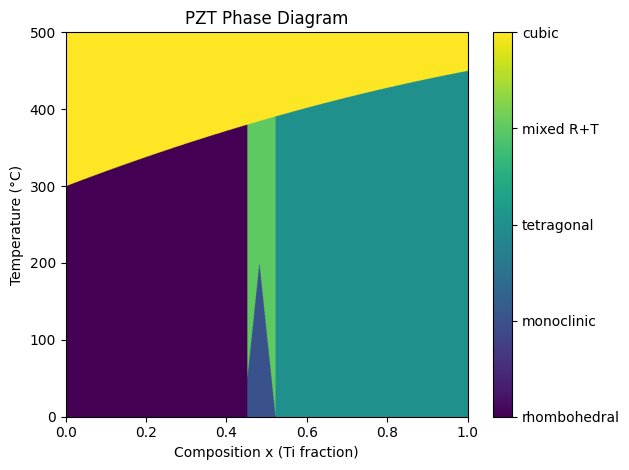

In [23]:
im = plt.imshow(phase,
           origin='lower',
           extent=(xx.min(), xx.max(), tt.min(), tt.max()),
           aspect='auto'
           )
# create colorbar
cbar = plt.colorbar(im)

# set tick positions and labels
tick_positions = list(enc_phases.values())
tick_labels = list(enc_phases.keys())

cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)

# optionally rotate labels for readability
plt.setp(cbar.ax.get_yticklabels(), rotation=0, ha='left')

plt.xlabel("Composition x (Ti fraction)")
plt.ylabel("Temperature (°C)")
plt.title("PZT Phase Diagram")
plt.tight_layout()
plt.show()

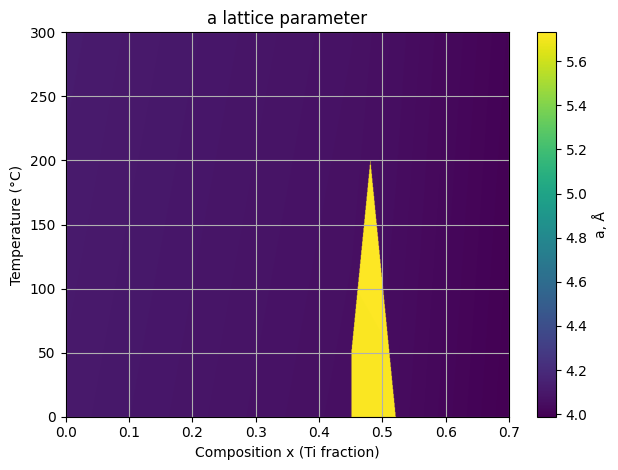

In [24]:
#define region of interest in the Phase Diagramm
tt = np.linspace(0, 300, 1000)
xx = np.linspace(0, .7, 1000)


TT, XX = np.meshgrid(tt, xx, indexing="ij")
a = np.zeros_like(TT)

enc_phases = {}
for i in range(TT.shape[0]):
  for j in range(TT.shape[1]):
    res_dict = pzt_phase(XX[i,j], TT[i,j])
    aa = res_dict['parameters']['a']

    if isinstance(aa, tuple):
      w_t = list(res_dict['parameters']['phase_fraction'].values())
      aa =(aa[0]*w_t[0] + aa[1]*w_t[1])

    a[i,j] = aa

im = plt.imshow(a,
           origin='lower',
           extent=(xx.min(), xx.max(), tt.min(), tt.max()),
           aspect='auto',)
# create colorbar
cbar = plt.colorbar(im, label="a, Å")

plt.xlabel("Composition x (Ti fraction)")
plt.ylabel("Temperature (°C)")
plt.title("a lattice parameter")
plt.grid()
plt.tight_layout()


# 2. XRD Simulator

=====================================================

### CRYSTALBUILDER: UNIVERSAL STRUCTURE AND XRD GENERATOR

=====================================================

This class constructs crystallographic models and corresponding X-ray
diffraction (XRD) patterns from provided symmetry and lattice parameters.
It supports both single-phase and mixed-phase (e.g., MPB) systems using
pymatgen’s `Lattice` and `Structure` objects together with the
`XRDCalculator` module.

Purpose:
The class is designed to bridge phenomenological phase-field or
thermodynamic models (such as `pzt_phase`) with crystallographic
and diffraction-based observables. It enables rapid visualization
of composition–temperature-dependent structural evolution.

Key features:]

• Supports multiple crystal symmetries:
cubic, tetragonal, rhombohedral, monoclinic, orthorhombic,
hexagonal, and triclinic.

• Accepts either single-phase parameters or mixed-phase descriptions
with phase fractions (e.g., "rhombohedral" + "tetragonal").

• Generates pymatgen `Structure` objects and simulates XRD patterns
for each phase, including Gaussian broadening to approximate
instrumental effects.

Internal workflow:

1. `__init__` initializes with symmetry, parameters, and optional
   species/atomic coordinates. If `phase_fraction` is present in
   `parameters`, it automatically constructs multiple structures
   with appropriate weighting.
2. `_build_lattice()` creates a single `Lattice` instance based on
   crystal symmetry and metric tensor parameters.
3. `_build_mixed_lattices()` handles coexistence regions by building
   several lattices, each associated with its phase fraction and
   symmetry type. Parameters can be tuples or scalars.
4. `broaden_pattern()` converts discrete ("stick") XRD peaks into a
   continuous profile using Gaussian broadening with specified FWHM.
5. `get_xrd_pattern()` calculates the combined diffraction intensity
   over a 2θ grid, summing phase contributions according to their
   fractions and normalizing the total intensity.
6. `summary()` provides a compact report of all generated structures
   and associated parameters.

Typical usage:

builder = CrystalBuilder(symmetry, params)

pattern = builder.get_xrd_pattern()

plt.plot(pattern["2theta"], pattern["intensity"])

This implementation provides a compact yet extensible framework for
constructing structure-based diffraction models directly from
composition–temperature–phase diagrams, supporting both fundamental
analysis and AI-driven materials discovery workflows.


In [25]:
import numpy as np
from pymatgen.core import Lattice, Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

class CrystalBuilder:
    """
    Universal structure + XRD pattern generator supporting mixed phases (MPB).
    """

    def __init__(self, symmetry, parameters, species=None, coords=None):
        self.symmetry = symmetry.lower()
        self.parameters = parameters
        self.species = species or ["A", "B", "O", "O", "O"]
        self.coords = coords or [
            [0, 0, 0], [0.5, 0.5, 0.5],
            [0.5, 0.5, 0.0], [0.5, 0.0, 0.5], [0.0, 0.5, 0.5]
        ]

        # If mixed phases (e.g., MPB), store multiple structures
        if "phase_fraction" in parameters:
            self.structures = self._build_mixed_lattices()
        else:
            self.lattice = self._build_lattice()
            self.structure = Structure(self.lattice, self.species, self.coords)
            self.structures = {self.symmetry: (self.structure, 1.0)}

    # -------------------------------------------------------------
    def _build_lattice(self):
        """Build pymatgen Lattice from symmetry and parameters."""
        p = self.parameters
        sym = self.symmetry
        sg_map = {
            "p4mm": "tetragonal",
            "r3m": "rhombohedral",
            "r3c": "rhombohedral",
            "cm": "monoclinic",
            "pm-3m": "cubic"
        }
        sym = sg_map.get(sym, sym)

        if sym == "cubic":
            return Lattice.cubic(p["a"])
        elif sym == "tetragonal":
            return Lattice.tetragonal(p["a"], p["c"])
        elif sym == "rhombohedral":
            return Lattice.rhombohedral(p["a"], p.get("alpha", 89.9))
        elif sym == "monoclinic":
            return Lattice.monoclinic(p["a"], p["b"], p["c"], p.get("beta", 90.0))
        else:
            raise ValueError(f"Unknown symmetry type: {sym}")

    # -------------------------------------------------------------
    def _build_mixed_lattices(self):
        """
        Handle mixed-phase systems (e.g., MPB, solid solutions).
        Automatically detects available symmetries and constructs appropriate lattices.
        """
        p = self.parameters
        fractions = p["phase_fraction"]
        lattices = {}

        # Helper to safely extract tuple or scalar parameter
        def get_param(name, idx, default=None):
            val = p.get(name, default)
            if isinstance(val, (list, tuple)):
                return val[idx]
            return val

        # Map of symmetry → corresponding pymatgen lattice constructor
        lattice_builders = {
            "cubic": lambda i: Lattice.cubic(get_param("a", i)),
            "tetragonal": lambda i: Lattice.tetragonal(get_param("a", i), get_param("c", i)),
            "orthorhombic": lambda i: Lattice.orthorhombic(
                get_param("a", i), get_param("b", i), get_param("c", i)
            ),
            "hexagonal": lambda i: Lattice.hexagonal(get_param("a", i), get_param("c", i)),
            "rhombohedral": lambda i: Lattice.rhombohedral(
                get_param("a", i), get_param("alpha", i, 89.9)
            ),
            "monoclinic": lambda i: Lattice.monoclinic(
                get_param("a", i), get_param("b", i), get_param("c", i), get_param("beta", i, 90.0)
            ),
            "triclinic": lambda i: Lattice.from_parameters(
                get_param("a", i), get_param("b", i), get_param("c", i),
                get_param("alpha", i, 90), get_param("beta", i, 90), get_param("gamma", i, 90)
            ),
        }

        # Iterate over each phase (e.g. "rhombohedral", "tetragonal", "cubic" ...)
        for i, (phase_name, frac) in enumerate(fractions.items()):
            phase_key = phase_name.lower()
            if phase_key not in lattice_builders:
                raise ValueError(f"Unsupported symmetry: {phase_key}")

            lattice = lattice_builders[phase_key](i)
            structure = Structure(lattice, self.species, self.coords)
            lattices[phase_key] = (structure, frac)

        return lattices

    # -------------------------------------------------------------
    def broaden_pattern(self, two_theta, intensities, two_theta_range=(10, 80), step=0.01, fwhm=0.05):
        """Return a smooth diffraction pattern from stick data."""
        grid = np.arange(two_theta_range[0], two_theta_range[1], step)
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))
        I = np.zeros_like(grid)
        for t, h in zip(two_theta, intensities):
            I += h * np.exp(-0.5 * ((grid - t)/sigma)**2)
        return grid, I / I.max()

    # -------------------------------------------------------------
    def get_xrd_pattern(self, wavelength="CuKa", two_theta_range=(10, 80), step=0.01, fwhm=0.1):
        """Compute XRD pattern (supports single or mixed phase)."""
        calc = XRDCalculator(wavelength=wavelength)
        tt = np.arange(two_theta_range[0], two_theta_range[1], step)
        I_total = np.zeros_like(tt)
        patterns = []
        for name, (struct, weight) in self.structures.items():
            patt = calc.get_pattern(struct)
            patterns.append(patt)
            tt_b, I_b = self.broaden_pattern(np.array(patt.x), np.array(patt.y),
                                             two_theta_range, step, fwhm)
            I_total += weight * np.interp(tt, tt_b, I_b)

        return {"2theta": tt, "intensity": I_total / I_total.max(), "components": self.structures, 'patterns': patterns}

    # -------------------------------------------------------------
    def summary(self):
        """Return parameters and structures."""
        return {"symmetry": self.symmetry, "parameters": self.parameters, "structures": self.structures}


In [26]:
#estimate XRD spectra
x = .2
T = 400 #Celsius

phase_data = pzt_phase(x=x, T=T)
builder = CrystalBuilder(
    symmetry=phase_data["symmetry"],
    parameters=phase_data["parameters"],
    species=["Pb", {"Zr": 1-x, "Ti":x}, "O", "O", "O"]
)
pattern = builder.get_xrd_pattern( two_theta_range=(20, 60),)

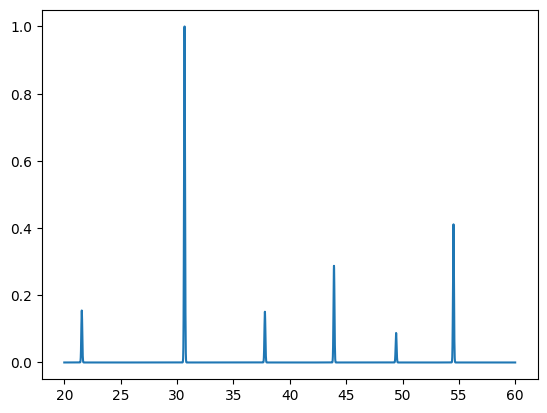

In [27]:
#Emulated experimental diffraction spectrum with Gaussian peak broadening to mimic instrumental effects.
plt.plot(pattern['2theta'], pattern['intensity'])

In [28]:
print('Peak position:')
print(pattern['patterns'][0].x)

print('Intensities:')
print(pattern['patterns'][0].y)

Peak position:
[21.55355857 30.66666847 37.79357869 43.92088887 49.43028248 54.51798379
 63.85805188 68.24298871 72.49760537 76.65463338 80.74116311 84.78062408
 88.79418303]
Intensities:
[ 15.47407559 100.          15.10501294  28.68038234   8.75393185
  41.02580669  18.04317081   4.68742064  17.97862457   5.46803663
   6.14172669   2.34131429  22.57890424]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Convergenc

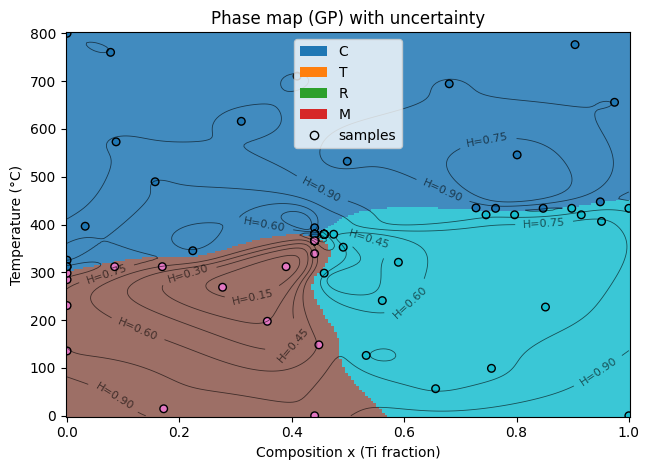

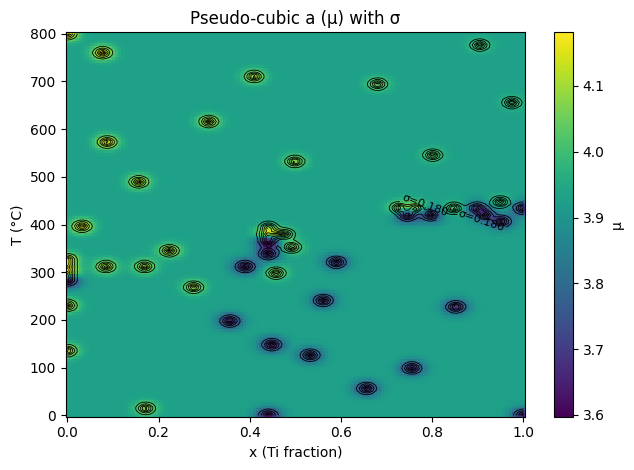

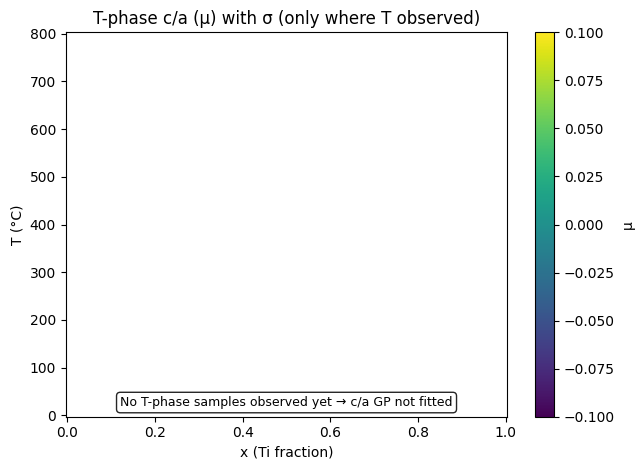

In [31]:
# =========================
# Active mapping add-on (works with your pzt_phase() + CrystalBuilder)
# =========================
import math, numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.exceptions import NotFittedError

# (Assumed available from your environment)
# from your_module import pzt_phase, CrystalBuilder

# ---- Adapter over YOUR simulator: returns (two_theta_deg, intensity) for given (x,T) ----
def simulate_xrd(x: float, T: float):
    phase_data = pzt_phase(x=float(x), T=float(T))   # <- from your file
    builder = CrystalBuilder(
        symmetry=phase_data["symmetry"],
        parameters=phase_data["parameters"],
        species=["Pb", {"Zr": 1-x, "Ti": x}, "O", "O", "O"]
    )
    patt = builder.get_xrd_pattern(two_theta_range=(20, 60), step=0.02, fwhm=0.10)
    return np.asarray(patt["2theta"]), np.asarray(patt["intensity"])

# =========================
# Feature extraction (peak split / asymmetry near strongest mid-angle peak)
# =========================
SMOOTH_SIGMA = 1.0
PEAK_HEIGHT_FRAC = 0.05
PEAK_DISTANCE_DEG = 0.15
ASYM_THRESH = 0.06

def _window_mask(tt, lo, hi): return (tt >= lo) & (tt <= hi)

def _d_spacing(tt_deg, wavelength_A=1.5406):
    theta = np.deg2rad(tt_deg / 2.0)
    s = np.sin(theta)
    s[s == 0] = 1e-12
    return wavelength_A / (2.0 * s)

def _pseudo_cubic_a(d_vals):
    if d_vals.size == 0:
        return np.nan
    d_sorted = np.sort(d_vals)
    d_star = float(d_sorted[int(0.4*len(d_sorted))])
    a_pc = 2.0 * d_star
    # mild sanity fallback
    if not (3.5 <= a_pc <= 4.5):
        a_pc = 2.3 * float(np.nanmean(d_vals))
    return a_pc

def featurize_xrd(tt, I):
    I = gaussian_filter1d(I.astype(float), sigma=SMOOTH_SIGMA)
    tt = tt.astype(float)

    # global peaks
    height = float(I.max()) * max(0.03, PEAK_HEIGHT_FRAC)
    min_dist_pts = max(1, int(max(0.05, PEAK_DISTANCE_DEG) / max(1e-6, np.diff(tt).mean())))
    peaks, _ = find_peaks(I, height=height, distance=min_dist_pts)
    peak_tt = tt[peaks]
    d_all = _d_spacing(peak_tt)

    # auto mid-angle window 30–60° around tallest peak
    mg = (tt >= 30.0) & (tt <= 60.0)
    if np.any(mg):
        tt_loc = tt[mg][np.argmax(I[mg])]
        win_lo, win_hi = tt_loc - 1.2, tt_loc + 1.2
    else:
        win_lo, win_hi = 44.0, 48.0
    m200 = _window_mask(tt, win_lo, win_hi)

    if np.any(m200):
        I200, tt200 = I[m200], tt[m200]
        p200, _ = find_peaks(I200, height=I200.max()*0.25, distance=max(1, int(0.05/np.diff(tt200).mean())))
        # local FWHM → adaptive split threshold
        if len(p200):
            j = p200[np.argmax(I200[p200])]
            mu = tt200[j]
            w = np.clip(I200/(I200.sum()+1e-12), 1e-12, None)
            fwhm_est = 2.355*np.sqrt(((tt200-mu)**2 * w).sum())
        else:
            fwhm_est = 0.15

        adaptive = max(0.001, 0.8 * fwhm_est / max(1e-6, (win_lo+win_hi)/2.0))
        p200, _ = find_peaks(I200, height=I200.max()*0.2, distance=max(1, int(0.08/np.diff(tt200).mean())))
        n_peaks_200 = len(p200)
        s200, ca_est = 0.0, 1.0

        if n_peaks_200 >= 2:
            idx2 = np.argsort(I200[p200])[::-1][:2]
            tpair = np.sort(tt200[p200][idx2])
            center = tpair.mean()
            delta = tpair[1] - tpair[0]
            s_raw = float(delta / max(1e-6, center))
            if s_raw > adaptive:
                s200 = s_raw
                ca_est = 1.0 + 10.0 * s200

        # asymmetry
        w = I200/(I200.sum()+1e-12)
        mu = (w*tt200).sum()
        sig = math.sqrt((w*((tt200-mu)**2)).sum()+1e-12)
        skew_200 = float((w*(((tt200-mu)/(sig+1e-12))**3)).sum())
    else:
        n_peaks_200, s200, skew_200, ca_est = 0, 0.0, 0.0, 1.0

    return {
        "s200": float(s200),
        "n_peaks_200": int(n_peaks_200),
        "skew_200": float(skew_200),
        "a_pc_est": float(_pseudo_cubic_a(d_all)),
        "ca_est": float(ca_est),
        "peak_count": int(len(peaks)),
    }

def label_phase(fp):
    # T if robust split; M if strong asymmetry; C only if simple/unsplit; else R
    if fp["s200"] >= 0.002 and fp["n_peaks_200"] >= 2:
        return "T"
    if abs(fp["skew_200"]) > ASYM_THRESH:
        return "M"
    if fp["s200"] < 0.0015 and fp["n_peaks_200"] <= 1 and fp["peak_count"] <= 8:
        return "C"
    return "R"

# =========================
# GP models
# =========================
PHASES = ["C","T","R","M"]
PID = {p:i for i,p in enumerate(PHASES)}
IDP = {i:p for p,i in PID.items()}

def _entropy(p):
    p = np.clip(p, 1e-12, 1.0)
    return -np.sum(p*np.log(p), axis=1)

class PhaseGP:
    def __init__(self, l=0.15):
        ker = C(1.0,(1e-2,1e2)) * RBF(l,(1e-2,10.0))
        self.model = make_pipeline(
            StandardScaler(),
            GaussianProcessClassifier(ker, multi_class='one_vs_rest', n_restarts_optimizer=2)
        )
        self.X=None
        self.y=None

    def fit(self, X, y_lbl):
        y = np.array([PID[v] for v in y_lbl])
        self.X = X.copy()
        self.y = y.copy()
        self.model.fit(self.X, self.y)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def predict(self, X):
        return np.array([IDP[i] for i in self.model.predict(X)])

class LatticeGP:
    """Gaussian Process wrapper with a 'safe' predictor returning NaNs if unfitted."""
    def __init__(self, l=0.2):
        ker = C(1.0,(1e-3,1e3)) * RBF(l,(1e-2,10.0))
        self.model = make_pipeline(
            StandardScaler(),
            GaussianProcessRegressor(ker, alpha=1e-4, normalize_y=True, n_restarts_optimizer=2)
        )
        self._fitted = False

    def fit(self, X, y):
        self.model.fit(X, y.astype(float))
        self._fitted = True

    def predict(self, X):
        if not self._fitted:
            raise NotFittedError("LatticeGP not fitted")
        return self.model.predict(X, return_std=True)

    def predict_safe(self, X, fill_mu=np.nan, fill_std=np.nan):
        if not self._fitted:
            n = len(X)
            return (np.full(n, fill_mu, dtype=float),
                    np.full(n, fill_std, dtype=float))
        return self.predict(X)

# =========================
# Active learner
# =========================
class ActiveMapper:
    def __init__(self, sim_fn, x_bounds=(0.0,1.0), T_bounds=(0.0,800.0), seed=7):
        self.sim = sim_fn
        self.xb, self.Tb = x_bounds, T_bounds
        self.rng = np.random.default_rng(seed)
        self.XT = []
        self.labels = []
        self.a_pc = []
        self.ca = []
        self.clf = PhaseGP()
        self.gp_a = LatticeGP()
        self.gp_ca = LatticeGP()  # only fits on T-phase points

    def _lhs(self, n):
        bounds = [self.xb, self.Tb]
        d = len(bounds)
        cut = np.linspace(0, 1, n+1)
        u = self.rng.random((n, d))
        a, b = cut[:n, None], cut[1:, None]
        pts = a + (b - a) * u
        for j in range(d): self.rng.shuffle(pts[:, j])
        for j, (lo, hi) in enumerate(bounds):
            pts[:, j] = lo + pts[:, j] * (hi - lo)
        return pts

    def _observe(self, x, T):
        tt, I = self.sim(x, T)
        fp = featurize_xrd(tt, I)
        ph = label_phase(fp)
        self.XT.append([x, T])
        self.labels.append(ph)
        self.a_pc.append(fp["a_pc_est"])
        self.ca.append(fp["ca_est"])

    def _fit(self):
        X = np.array(self.XT)
        self.clf.fit(X, self.labels)
        self.gp_a.fit(X, np.array(self.a_pc))
        mask_T = np.array([l == "T" for l in self.labels])
        if mask_T.any():
            self.gp_ca.fit(X[mask_T], np.array(self.ca)[mask_T])
        # else: gp_ca remains unfitted; plotting uses predict_safe()

    def _candidates(self, nx=60, nT=60):
        x = np.linspace(*self.xb, nx)
        T = np.linspace(*self.Tb, nT)
        Xg, Tg = np.meshgrid(x, T)
        return np.column_stack([Xg.ravel(), Tg.ravel()])

    def _acquire(self, Xg, k=1):
        if len(self.XT) < 4:
            idx = self.rng.choice(len(Xg), size=k, replace=False)
            return Xg[idx]

        P = self.clf.predict_proba(Xg)
        H = _entropy(P)
        margin = 1.0 - P.max(axis=1)
        s = 0.7 * H + 0.3 * margin

        # top-k by acquisition score
        top = np.argpartition(-s, kth=min(k, len(s)-1))[:k]

        # avoid re-sampling too close to known points
        Xknown = np.array(self.XT)
        chosen = []
        dx = 0.01 * (self.xb[1] - self.xb[0])
        dT = 0.01 * (self.Tb[1] - self.Tb[0])
        for i in top[np.argsort(-s[top])]:
            close = (np.abs(Xg[i, 0] - Xknown[:, 0]) < dx) & (np.abs(Xg[i, 1] - Xknown[:, 1]) < dT)
            if not np.any(close):
                chosen.append(i)
            if len(chosen) >= k:
                break
        if not chosen:
            chosen = list(top[:k])

        return Xg[np.array(chosen)]

    def run(self, scout_n=20, budget=60, batch=1):
        # initial Latin hypercube scout
        for x, T in self._lhs(scout_n):
            self._observe(float(x), float(T))
        self._fit()

        remaining = int(budget)
        while remaining > 0:
            Xg = self._candidates()
            for (x, T) in self._acquire(Xg, k=min(batch, remaining)):
                self._observe(float(x), float(T))
                remaining -= 1
                if remaining <= 0:
                    break
            self._fit()

    def plot_phase_map(self, nx=200, nT=200):
        Xg = self._candidates(nx, nT)
        P = self.clf.predict_proba(Xg)
        lab = np.argmax(P, axis=1)
        H = _entropy(P)

        x = np.linspace(*self.xb, nx)
        T = np.linspace(*self.Tb, nT)
        Xg2, Tg2 = np.meshgrid(x, T)
        Z = lab.reshape(nT, nx)
        U = H.reshape(nT, nx)

        fig, ax = plt.subplots(figsize=(6.6, 4.8))
        im = ax.pcolormesh(Xg2, Tg2, Z, shading="auto", cmap="tab10", alpha=0.85)
        cs = ax.contour(Xg2, Tg2, U, levels=6, colors="k", linewidths=0.6, alpha=0.6)
        ax.clabel(cs, inline=1, fontsize=8, fmt="H=%.2f")

        XT = np.array(self.XT)
        ph_ids = np.array([PID[p] for p in self.labels])
        sc = ax.scatter(XT[:, 0], XT[:, 1], c=ph_ids, cmap="tab10", edgecolor="k", s=30, label="samples")

        ax.set_xlabel("Composition x (Ti fraction)")
        ax.set_ylabel("Temperature (°C)")
        ax.set_title("Phase map (GP) with uncertainty")

        # Legend: phases + samples
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        phase_handles = [Patch(facecolor=plt.cm.tab10(PID[p]/10.0), edgecolor='none', label=p) for p in PHASES]
        sample_handle = Line2D([0],[0], marker='o', color='w', label='samples',
                               markerfacecolor='none', markeredgecolor='k', markersize=6, linewidth=0)
        ax.legend(handles=phase_handles + [sample_handle], frameon=True, loc="best")

        plt.tight_layout()
        return ax

    def plot_lattice_maps(self, which="a_pc", nx=140, nT=140):
        Xg = self._candidates(nx, nT)
        if which == "a_pc":
            mu, std = self.gp_a.predict_safe(Xg)  # always fitted in _fit(), but safe anyway
            title = "Pseudo-cubic a (μ) with σ"
        elif which == "ca_T":
            # safe: if no T-phase seen yet, NaN map with annotation
            mu, std = self.gp_ca.predict_safe(Xg)
            title = "T-phase c/a (μ) with σ (only where T observed)"
        else:
            raise ValueError("which must be 'a_pc' or 'ca_T'")

        x = np.linspace(*self.xb, nx)
        T = np.linspace(*self.Tb, nT)
        Xg2, Tg2 = np.meshgrid(x, T)
        M = mu.reshape(nT, nx)
        S = std.reshape(nT, nx)

        fig, ax = plt.subplots(figsize=(6.6, 4.8))
        im = ax.pcolormesh(Xg2, Tg2, M, shading="auto")
        cs = ax.contour(Xg2, Tg2, S, levels=6, colors='k', linewidths=0.6)
        ax.clabel(cs, inline=1, fontsize=8, fmt="σ=%.3f")

        ax.set_xlabel("x (Ti fraction)")
        ax.set_ylabel("T (°C)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, label="μ")

        if np.all(np.isnan(M)):
            ax.text(0.5, 0.02,
                    "No T-phase samples observed yet → c/a GP not fitted",
                    transform=ax.transAxes, ha="center", va="bottom", fontsize=9,
                    bbox=dict(facecolor="w", alpha=0.85, boxstyle="round"))

        plt.tight_layout()
        return ax

# =========================
# Run the sequential exploration (SMALLEST STEPS: batch=1)
# =========================
if __name__ == "__main__":
    mapper = ActiveMapper(simulate_xrd, x_bounds=(0.0, 1.0), T_bounds=(0.0, 800.0), seed=42)
    mapper.run(scout_n=24, budget=60, batch=1)   # strictly sequential after a small scout

    # Phase fields + lattice maps
    mapper.plot_phase_map()
    mapper.plot_lattice_maps("a_pc")
    mapper.plot_lattice_maps("ca_T")
    plt.show()


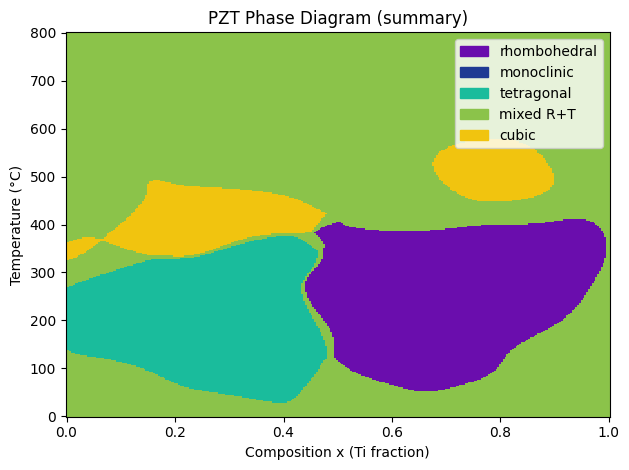

In [32]:
# After mapper.run(...) has finished
nx, nT = 300, 300
Xg = mapper._candidates(nx, nT)
P = mapper.clf.predict_proba(Xg)             # [N, 4] probs for C,T,R,M
top2 = np.sort(P, axis=1)[:, -2:]            # largest two probs
labels = P.argmax(axis=1)                    # 0=C,1=T,2=R,3=M

# Optional "mixed" region where top two phases are close or entropy high
from scipy.stats import entropy
H = entropy(P.T)                              # natural log
mixed = ((top2[:,1] - top2[:,0]) < 0.10) | (H > 0.75)

# Remap: 0=C,1=T,2=R,3=M,4=MIXED
labels_mixed = labels.copy()
labels_mixed[mixed] = 4

# Grid & plot
x = np.linspace(*mapper.xb, nx)
T = np.linspace(*mapper.Tb, nT)
Xg2, Tg2 = np.meshgrid(x, T)
Z = labels_mixed.reshape(nT, nx)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define a tidy palette: R (violet), M (navy), T (teal), Mixed (yellow-green), C (gold)
phase_names = ["Cubic", "Tetragonal", "Rhombohedral", "Monoclinic", "Mixed R+T"]
phase_order_to_color = {
    2: "#6a0dad",  # R
    3: "#1f3a93",  # M
    1: "#1abc9c",  # T
    4: "#8bc34a",  # Mixed
    0: "#f1c40f",  # C
}
cmap_list = [phase_order_to_color[i] for i in [0,1,2,3,4]]
cmap = mcolors.ListedColormap(cmap_list)
bounds = [-0.5,0.5,1.5,2.5,3.5,4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(6.4,4.8))
im = ax.pcolormesh(Xg2, Tg2, Z, shading="auto", cmap=cmap, norm=norm)
ax.set_xlabel("Composition x (Ti fraction)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("PZT Phase Diagram (summary)")

# Custom legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color=phase_order_to_color[2], label="rhombohedral"),
    Patch(color=phase_order_to_color[3], label="monoclinic"),
    Patch(color=phase_order_to_color[1], label="tetragonal"),
    Patch(color=phase_order_to_color[4], label="mixed R+T"),
    Patch(color=phase_order_to_color[0], label="cubic"),
]
ax.legend(handles=legend_items, frameon=True, loc="upper right")
plt.tight_layout(); plt.show()
